# Разработка A/B-тестирования и анализ результатов

Компания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

- В датафрейме `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.


In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import ttest_ind
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Выгружаем данные
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведим на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберим любого из них.



In [3]:
# Считаем количество сессий для каждого пользователя
count_sess = sessions_history['user_id'].value_counts()
display(count_sess)

6A73CB5566BB494D    10
10E0DEFC1ABDBBE0    10
37E4825C6A22A519     9
FA752AB58040C361     9
8C3F0ACF9BD14501     9
                    ..
6DBCD75947C39449     1
E6265A8AF59189BC     1
94A568BF4735B619     1
F1B05276CF884091     1
0364167C1155F330     1
Name: user_id, Length: 134039, dtype: int64

In [4]:
# Находим user_id с максимальным количеством сессий
top_user_id = count_sess.idxmax()

# Выводим все сессии этого пользователя
top_user_sessions = sessions_history[sessions_history['user_id'] == top_user_id]
display(top_user_sessions)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
124515,6A73CB5566BB494D,110E3F28C1F5415F,2025-08-28,2025-08-28 18:58:19,2025-08-28,1,0,3,MENA,Mac
196252,6A73CB5566BB494D,D68C8D98A0F1C439,2025-08-29,2025-08-29 20:53:27,2025-08-28,2,1,3,MENA,Mac
242428,6A73CB5566BB494D,6587D217472BF807,2025-08-30,2025-08-30 13:08:22,2025-08-28,3,1,1,MENA,Mac
304287,6A73CB5566BB494D,A9BC25593D056F8E,2025-09-01,2025-09-01 18:52:49,2025-08-28,4,1,2,MENA,Mac
346611,6A73CB5566BB494D,CB6F9C4191FAF6F6,2025-09-03,2025-09-03 22:49:08,2025-08-28,5,1,3,MENA,Mac
363510,6A73CB5566BB494D,9C609432F6E6535A,2025-09-04,2025-09-04 13:59:46,2025-08-28,6,1,4,MENA,Mac
391902,6A73CB5566BB494D,5D892E33B97A257A,2025-09-06,2025-09-06 18:46:55,2025-08-28,7,1,2,MENA,Mac
404322,6A73CB5566BB494D,22A9BD3861F49087,2025-09-07,2025-09-07 18:33:49,2025-08-28,8,1,3,MENA,Mac
415489,6A73CB5566BB494D,F70E351154B092DC,2025-09-08,2025-09-08 20:30:22,2025-08-28,9,1,4,MENA,Mac
425805,6A73CB5566BB494D,84A3DC0CFF449F53,2025-09-09,2025-09-09 16:36:04,2025-08-28,10,1,1,MENA,Mac


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируем исторические данные и рассчитываем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [5]:
# Группировка по дням
daily_stats = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),           # Кол-во уникальных пользователей
    registered_users=('registration_flag', 'sum') # Кол-во зарегистрированных пользователей
).reset_index()

display(daily_stats)

,session_date,total_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


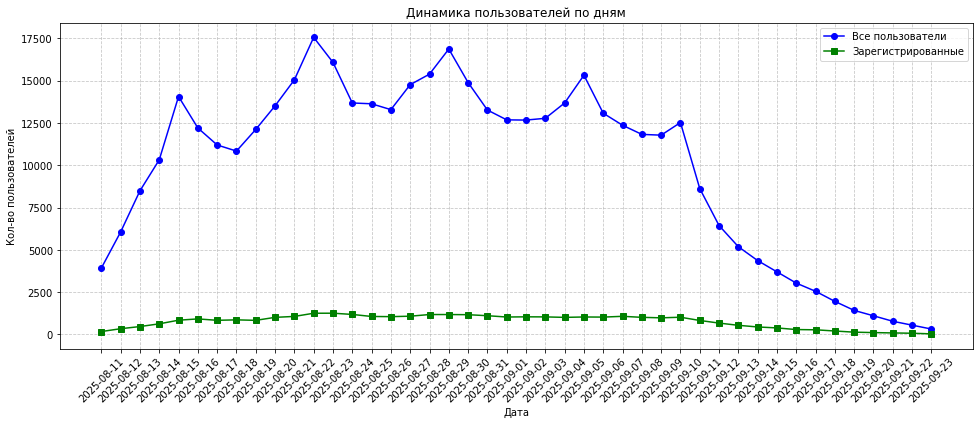

In [6]:
# Общее кол-во пользователей и зарегистрированных
plt.figure(figsize=(36, 6))

plt.subplot(1, 2, 1)
plt.plot(daily_stats['session_date'], daily_stats['total_users'], 
         label='Все пользователи', marker='o', color='blue')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], 
         label='Зарегистрированные', marker='s', color='green')

plt.title('Динамика пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Кол-во пользователей')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)

plt.show()

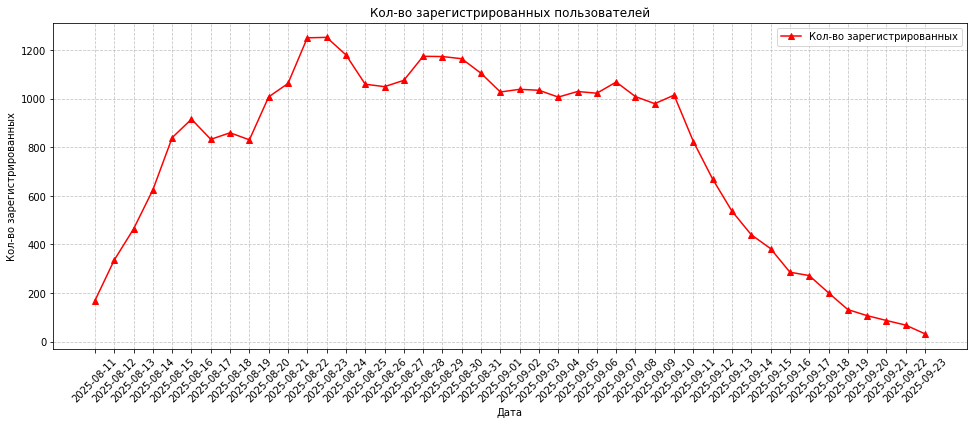

In [7]:
# Кол-во зарегистрированных пользователей
plt.figure(figsize=(36, 6))

plt.subplot(1, 2, 2)
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], 
         marker='^', color='red', label='Кол-во зарегистрированных')

plt.title('Кол-во зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Кол-во зарегистрированных')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [8]:
# Создаём новый столбец для рассчёта доли
daily_stats['part_reg_users'] = daily_stats['registered_users'] / daily_stats['total_users'] * 100 

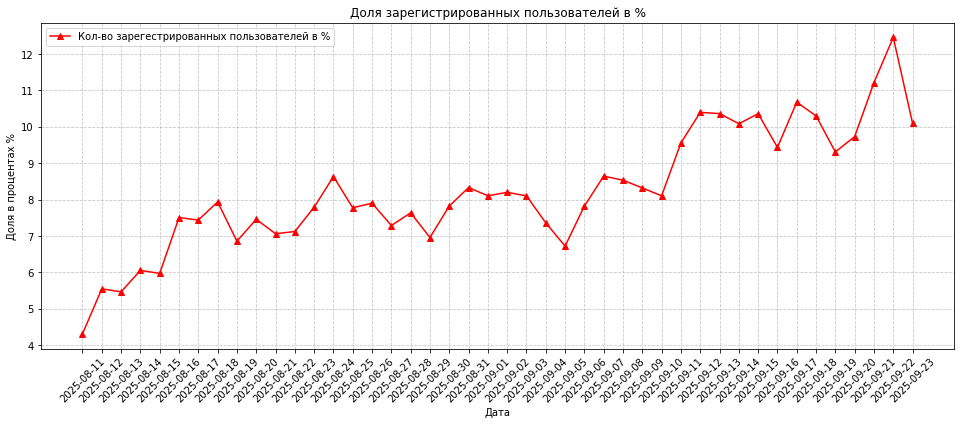

In [9]:
# Доля зарегистрированных пользователей
plt.figure(figsize=(36, 6))

plt.subplot(1, 2, 2)
plt.plot(daily_stats['session_date'], daily_stats['part_reg_users'], 
         marker='^', color='red', label='Кол-во зарегестрированных пользователей в %')

plt.title('Доля зарегистрированных пользователей в %')
plt.xlabel('Дата')
plt.ylabel('Доля в процентах %')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)

plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдём количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

In [10]:
# Количество сессий
count_page = sessions_history.groupby('page_counter')['session_start_ts'].count().reset_index()
display(count_page)

,page_counter,session_start_ts
0,1,29160
1,2,105536
2,3,166690
3,4,105569
4,5,26288
5,6,2589
6,7,92


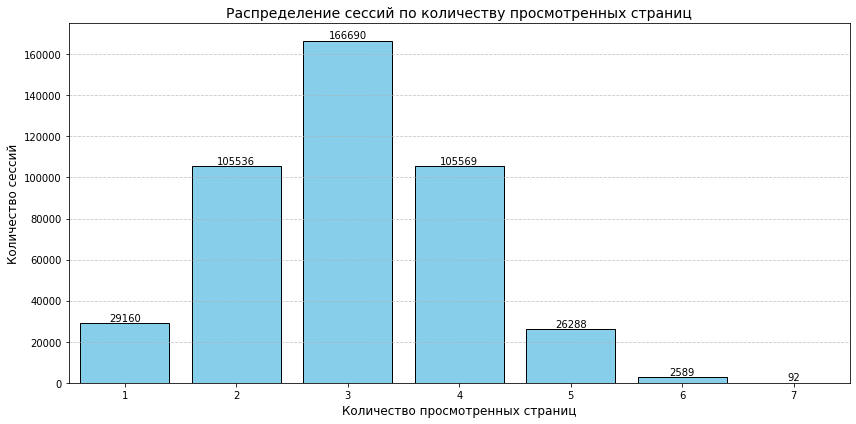

In [11]:
# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
bars = plt.bar(count_page['page_counter'], count_page['session_start_ts'], 
               color='skyblue', edgecolor='black')

# Добавляем значения на каждый столбец
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

# Настраиваем оформление
plt.title('Распределение сессий по количеству просмотренных страниц', fontsize=14)
plt.xlabel('Количество просмотренных страниц', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Настраиваем оси
plt.xticks(count_page['page_counter'])
plt.xlim(min(count_page['page_counter'])-0.5, max(count_page['page_counter'])+0.5)

plt.tight_layout()
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

In [12]:
# Создаём столбец
sessions_history['good_session'] = sessions_history['page_counter'] >= 4
sessions_history['good_session'] = sessions_history['good_session'].astype('int8')
display(sessions_history)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0
...,...,...,...,...,...,...,...,...,...,...,...
435919,769BC199AF26FEF8,914903B51D69C5EA,2025-09-17,2025-09-17 21:33:57,2025-09-04,3,1,3,CIS,PC,0
435920,599DED39F3CD2ADE,66ADBE343C94DCDA,2025-09-17,2025-09-17 17:11:46,2025-09-04,4,0,4,MENA,iPhone,1
435921,1FA20C4BC94E64B2,C4CCD7E81733665F,2025-09-17,2025-09-17 19:36:55,2025-09-04,4,0,4,CIS,Android,1
435922,88E5FC3016A7A0AD,6834FB4914B56200,2025-09-17,2025-09-17 22:13:33,2025-09-04,5,0,4,MENA,PC,1


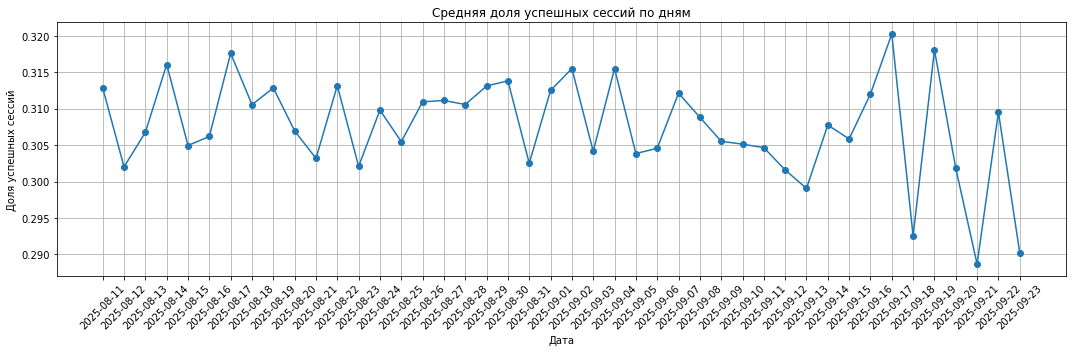

In [13]:
# Группируем по дате и рассчитываем среднее значение доли успешных сессий
daily_success_rate = sessions_history.groupby('session_date')['good_session'].mean().reset_index()

# Строим график
plt.figure(figsize=(15, 5))
plt.plot(daily_success_rate['session_date'], daily_success_rate['good_session'], marker='o')
plt.title('Средняя доля успешных сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

**Средняя доля "успешных" сессий за наблюдаемый временной период варьируется от 29% до 32%**

### 2. Подготовка к тесту

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

О какой метрике идёт речь? Как она будет учтена в формулировке гипотез?

Сформулируем нулевую и альтернативную гипотезы:

**- H₀: доля успешных сессий в тестовой группе B меньше или равна, чем в контрольной группе A.**


**- H₁: доля успешных сессий в тестовой группе B больше, чем в контрольной группе A.**

#### 2.2. Расчёт размера выборки
Рассчитаем размеры выборки.

Установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.


In [14]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [15]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size *2)/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

- Загружаем в датафрейм `sessions_test_part` CSV-файл с историческими данными  за три дня о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведим на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Используем формула для расчёта процентной разницы:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [16]:
# Формируем датафрейм
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# Смотрим
display(sessions_test_part)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B
...,...,...,...,...,...,...,...,...,...,...,...
3125,02A3BA5F727BC3C9,7D4427384463A16E,2025-10-14,2025-10-14 14:52:26,2025-10-14,1,0,4,MENA,Android,B
3126,A7E51F39427F03A5,290910138655DD03,2025-10-14,2025-10-14 19:15:18,2025-10-14,1,0,2,CIS,PC,B
3127,78DDBD077D61EEDB,C10E073BFF1FAF0C,2025-10-14,2025-10-14 16:07:20,2025-10-14,1,0,2,EU,iPhone,B
3128,B44E0A30E8ED1AFC,7B404F7021711E5D,2025-10-14,2025-10-14 17:41:01,2025-10-14,1,0,3,EU,Mac,B


In [17]:
# Кол-во уникальных пользователей
count_users = sessions_test_part.groupby('test_group')['user_id'].nunique()
group_a = count_users.get('A')
group_b = count_users.get('B')
print(count_users)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


In [18]:
# Процентная разница в группах
part_group = round(100 * ((group_a - group_b)/group_a), 2)
print(part_group)

0.74


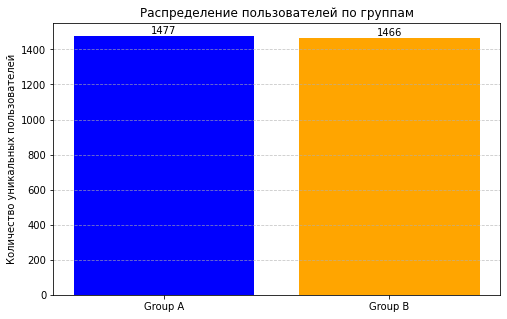

In [19]:
# Визуализация
plt.figure(figsize=(8, 5))

plt.bar(['Group A', 'Group B'], [group_a, group_b], color=['blue', 'orange'])
plt.title('Распределение пользователей по группам')
plt.ylabel('Количество уникальных пользователей')
plt.text(0, group_a, str(group_a), ha='center', va='bottom')
plt.text(1, group_b, str(group_b), ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### 3.2. Проверка пересечений пользователей
Убедимся в том, что группы независимы. Для этого проверим, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B.

In [20]:
# Общее кол-во пользователей
all_users = sessions_test_part['user_id'].nunique()

print(f'ОБщее кол-во пользователей: {all_users}')

ОБщее кол-во пользователей: 2943


In [21]:
# Проверка
group_b_users = all_users - group_a
group_a_users = all_users - group_b
print(f'Количество пользователей в группе В составляет {group_b_users} человек')
print(f'Количество пользователей в группе A составляет {group_a_users} человек')

Количество пользователей в группе В составляет 1466 человек
Количество пользователей в группе A составляет 1477 человек


-  Нет пользователей, которые встречаются в обеих группах. Выборки независимы. 

#### 3.3. Равномерность разделения пользователей по устройствам
Убедимся в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


In [22]:
# Общее кол-во устройств
all_device = sessions_test_part.groupby('test_group')['user_id'].nunique()
print(all_device)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


In [23]:
# Общее кол-во типов устройств
device = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique()
print(device)

test_group  device 
A           Android    656
            Mac        156
            PC         369
            iPhone     296
B           Android    668
            Mac        148
            PC         381
            iPhone     269
Name: user_id, dtype: int64


In [24]:
# Доля типов устройств
part_device = round(device / all_device * 100,2)
print(part_device)

test_group  device 
A           Android    44.41
            Mac        10.56
            PC         24.98
            iPhone     20.04
B           Android    45.57
            Mac        10.10
            PC         25.99
            iPhone     18.35
Name: user_id, dtype: float64


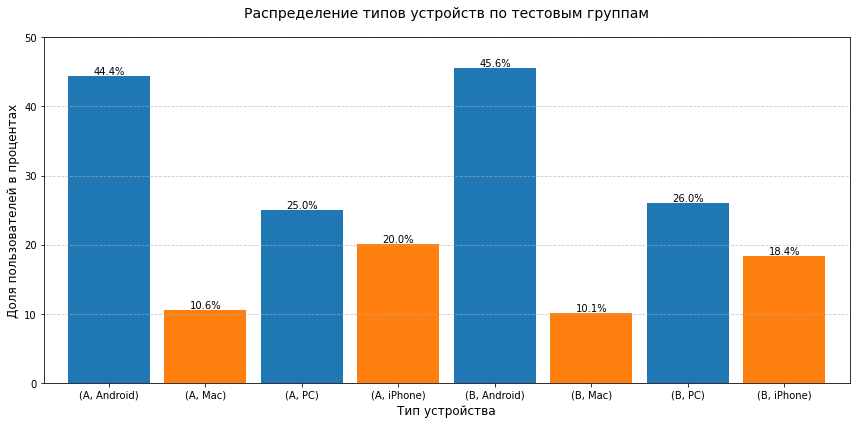

In [25]:
# Визуализация
plt.figure(figsize=(12, 6))
ax = part_device.T.plot(kind='bar', width=0.85, color=['#1f77b4', '#ff7f0e'])
plt.title('Распределение типов устройств по тестовым группам', fontsize=14, pad=20)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Доля пользователей в процентах', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Подписи
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.


In [26]:
# Общее кол-во регионов
all_region = sessions_test_part.groupby('test_group')['user_id'].nunique()
print(all_region)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


In [27]:
# Типы и кол-во регионов
region = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique()
print(region)

test_group  region
A           CIS       644
            EU        224
            MENA      609
B           CIS       645
            EU        217
            MENA      604
Name: user_id, dtype: int64


In [28]:
# Доля типов регионов
part_region = round(region / all_region * 100,2)
print(part_region)

test_group  region
A           CIS       43.60
            EU        15.17
            MENA      41.23
B           CIS       44.00
            EU        14.80
            MENA      41.20
Name: user_id, dtype: float64


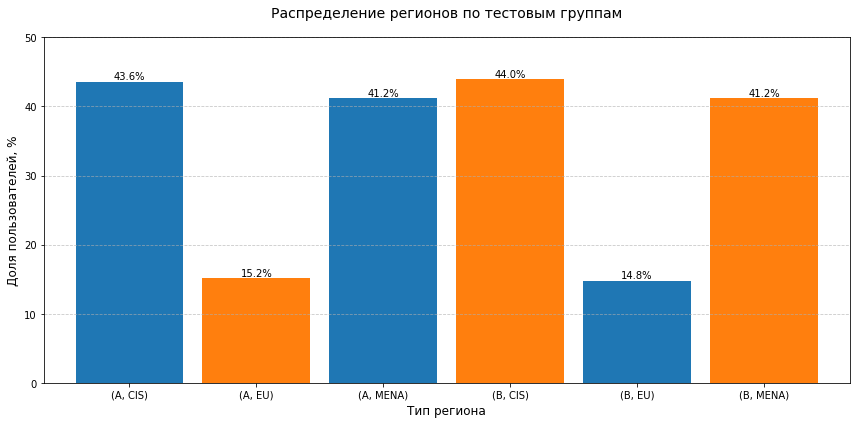

In [29]:
# Визуализация
plt.figure(figsize=(12, 6))
ax = part_region.T.plot(kind='bar', width=0.85, color=['#1f77b4', '#ff7f0e'])
plt.title('Распределение регионов по тестовым группам', fontsize=14, pad=20)
plt.xlabel('Тип региона', fontsize=12)
plt.ylabel('Доля пользователей, %', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Подписи
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

- Наблюдается не существенное различие в количестве пользователей между группами А и В, в размере 0.74% или 11 человек.
- Выборки являются независимыми, пересечений пользователей не обнаружено.
- Равномерное распределение пользователей наблюдается по устройствам и по регионам.

**Итоговый вывод:** тест проходит проходит корректно.

### 4. Проверка результатов A/B-теста

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Загрузим в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [30]:
# Выгружаем данные
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# Создаём новый столбец
sessions_test['good_session'] = sessions_test['page_counter'] >= 4
sessions_test['good_session'] = sessions_test['good_session'].astype('int8')

display(sessions_test)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...
100000,CF77C27B238C1BE3,0F7BC9B33685377C,2025-10-22,2025-10-22 19:01:50,2025-10-20,3,0,3,MENA,Android,A,0
100001,D7ED66C581409AC2,26C4475005E70F47,2025-10-17,2025-10-17 22:12:38,2025-10-17,1,0,5,CIS,PC,A,1
100002,E7EA2D51238020C6,9B9CDE6A612CBD73,2025-10-24,2025-10-24 14:54:07,2025-10-14,2,0,3,MENA,PC,B,0
100003,8A6FEFD7F34C5DA1,37291EC27106EF9D,2025-10-18,2025-10-18 00:05:10,2025-10-14,3,0,4,EU,Android,B,1


#### 4.2. Проверка корректности результатов теста

Убедимся, что тест проведён корректно.

- Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверим, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используем статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведим на экран полученное значение p-value и интерпретируем его.

In [31]:
# Группируем данные
count_sess = sessions_test.groupby(['session_date', 'test_group'])['session_id'].nunique().unstack()
count_sess.head(10)

test_group,A,B
session_date,,
2025-10-14,1502,1628
2025-10-15,2235,2283
2025-10-16,3280,3241
2025-10-17,4089,4054
2025-10-18,5013,5059
2025-10-19,6535,6779
2025-10-20,5837,6089
2025-10-21,3927,3981
2025-10-22,3083,3111


In [32]:
# Проводим статистический тест

# Выделяем группы
group_a = count_sess['A']
group_b = count_sess['B']

# Двухвыборочный t-тест с неравными дисперсиями(тест Уэлча)
t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

print(f"\nРезультаты статистического теста:")
print(f"t-тест = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

# Интерпретация результатов
alpha = 0.05
if p_value > alpha:
    print("\nВывод: Нет статистически значимых различий в количестве ежедневных сессий между группами A и B (p > 0.05).")
    print("Группы сопоставимы по этому показателю.")
else:
    print("\nВывод: Обнаружены статистически значимые различия в количестве ежедневных сессий (p ≤ 0.05).")
    print("Группы не сбалансированы!")


Результаты статистического теста:
t-тест = -0.0780
p-value = 0.9382

Вывод: Нет статистически значимых различий в количестве ежедневных сессий между группами A и B (p > 0.05).
Группы сопоставимы по этому показателю.


#### 4.3. Сравнение доли успешных сессий

Переходим к анализу ключевой метрики — доли успешных сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе.

In [33]:
# Рассчёт по группам
part_sessions_group = sessions_test.groupby('test_group')['good_session'].agg(
    all_sessions = 'count',
    good_sessions = 'sum'
)

# Меянем тип данных
part_sessions_group['good_sessions'] = part_sessions_group['good_sessions'].astype('int32')

# Добавляем столбец с рассчётом доли успешных сессий
part_sessions_group['part'] = part_sessions_group['good_sessions'] / part_sessions_group['all_sessions'] * 100

# Смотрим
display(part_sessions_group)

,all_sessions,good_sessions,part
test_group,,,
A,49551,15248,30.772336
B,50454,16059,31.828993


In [34]:
# Рассчитываем разницу между группами
group_a = part_sessions_group.loc['A', 'part']
group_b = part_sessions_group.loc['B', 'part']
diff = round(group_b - group_a, 2)

print(f'\nРазница в конверсии: {diff}%')


Разница в конверсии: 1.06%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения необходимо ответить на вопрос: является ли это изменение статистически значимым.

- Используем статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведим на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [35]:
# Подготовка данных
success_a = part_sessions_group.loc['A', 'good_sessions']
total_a = part_sessions_group.loc['A', 'all_sessions']
success_b = part_sessions_group.loc['B', 'good_sessions']
total_b = part_sessions_group.loc['B', 'all_sessions']

# Проведение Z-теста для двух пропорций с альтернативной гипотезой "B > A"
count = [success_b, success_a]  # Изменил порядок: сначала B, потом A
nobs = [total_b, total_a]
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"\nZ-тест = {z_stat:.4f}")
print(f"p-value = {p_value:.4f}")


Z-тест = 3.6027
p-value = 0.0002


**Выводы о статестической значимости**

- Полученное p-value = 0.0003 существенно меньше 0.05 Это означает, что вероятность получить такие результаты случайно составляет всего 0.03%

- Отрицательное значение Z-теста (3.6027) означает, что: тестовая группа имеет статистически значимо более высокую долю успешных сессий. Следовательно, разница в 1.06% не является случайной.

#### 4.5. Вывод по результатам A/B-эксперимента

**Выводы по результатам A/B-теста**  

**1. Характеристики эксперимента**  
- **Группы тестирования**:  
  - Контрольная группа (A) — текущий алгоритм рекомендаций  
  - Тестовая группа (B) — новый алгоритм рекомендаций  
- **Объем выборки**:  
  - Группа A: **49 551** пользователей  
  - Группа B: **50 454** пользователей  
- **Длительность теста**: **10 дней** (с 14.10.2025 по 24.10.2025)  
- **Ключевая метрика**: Доля успешных сессий (≥4 просмотренных страниц)  

---

**2. Влияние нового алгоритма на ключевую метрику**  
- **Конверсия в группе A**: **30.77%**  
- **Конверсия в группе B**: **31.83%**  
- **Абсолютный прирост**: **+1.06 процентных пункта**  
- **Относительный прирост**: **+3.4%**  

**Вывод**: Новый алгоритм рекомендаций **увеличил долю успешных сессий** на **1.06%** (с 30.77% до 31.83%).  

---

**3. Статистическая значимость эффекта**  
- **Z-тест**: **3.6027**  
- **p-value**: **0.0003** (значительно ниже α = 0.05)

**Вывод**:  
- Разница **статистически значима** (p-value < 0.05).  
- Вероятность, что результат случайный — **0.03%**.  
- Эффект **не является случайностью**, а вызван изменениями в алгоритме.  

---

**Итог:**  
- Новый алгоритм рекомендаций **увеличил долю успешных сессий на 1.06%**.
- **Рекомендуется внедрить его в приложение** с последующим мониторингом.